# Smollm


In [1]:
!pip install -q transformers datasets torch accelerate tokenizers

import re, math, torch, numpy as np, pandas as pd
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback
)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
print("="*60)
print("LOADING tweet_eval/sentiment")
print("="*60)

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
combined = concatenate_datasets([
    dataset["train"], dataset["validation"], dataset["test"]
])
print(f"Total tweets: {len(combined)}")


LOADING tweet_eval/sentiment
Total tweets: 59899


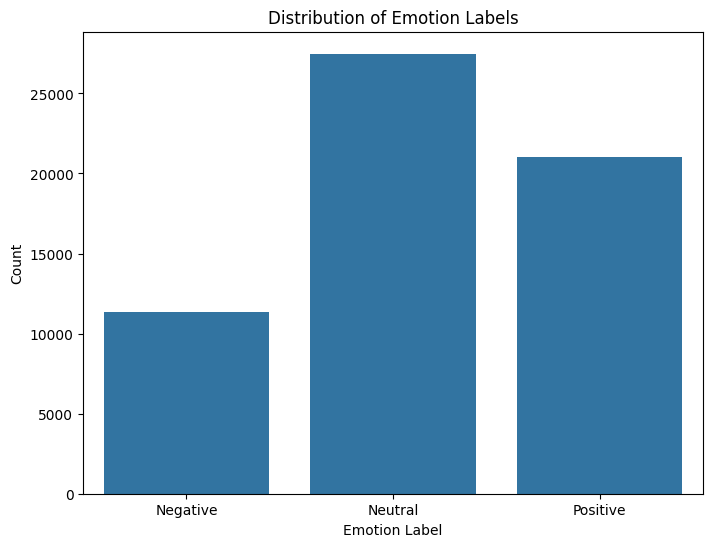

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the combined dataset to a pandas DataFrame for easier plotting
combined_df = combined.to_pandas()

# Plot the distribution of the 'label' column
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=combined_df)
plt.title('Distribution of Emotion Labels')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
# Assuming labels are 0: Negative, 1: Neutral, 2: Positive based on tweet_eval documentation
plt.xticks(ticks=[0, 1, 2], labels=['Negative', 'Neutral', 'Positive'])
plt.show()

In [ ]:
print("="*60)
print("CLEANING DATA & ADDING CONTROL TOKENS")
print("="*60)

SENTIMENT_MAP = {0: "[NEGATIVE]", 1: "[NEUTRAL]", 2: "[POSITIVE]"}

def clean_text(text):
    # Ensure the input is a string
    if not isinstance(text, str):
        return None
    text = re.sub(r'http\S+|@\w+|#', '', text)
    # Allow apostrophes, commas, periods, question marks, and exclamation points within words
    text = re.sub(r'[^A-Za-z0-9\s\'\.\,!?]', '', text)
    text = re.sub(r'([!?.,])\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Add a minimum length check and diversity check
    if len(text) < 20 or len(set(text.lower())) < 5: # Reduced diversity check to 5 unique characters
        return None
    return text

rows = []
for ex in combined:
    cleaned = clean_text(ex["text"])
    if cleaned:
        prefix = SENTIMENT_MAP[ex["label"]]
        rows.append({"text": f"{prefix} {cleaned}", "label": ex["label"]})

cleaned_ds = Dataset.from_pandas(pd.DataFrame(rows))
print(f"After cleaning: {len(cleaned_ds)} samples")

CLEANING DATA & ADDING CONTROL TOKENS


NameError: name 'Dataset' is not defined

In [ ]:
print("="*60)
print("CREATING BALANCED DATASET")
print("="*60)

df = cleaned_ds.to_pandas()
min_count = df["label"].value_counts().min()

balanced = []
for label in [0,1,2]:
    subset = cleaned_ds.filter(lambda x: x["label"] == label)
    balanced.append(subset.shuffle(seed=42).select(range(min_count)))

balanced_ds = concatenate_datasets(balanced).shuffle(seed=42)
print("Balanced size:", len(balanced_ds))
print(balanced_ds.to_pandas()["label"].value_counts())


CREATING BALANCED DATASET


Filter:   0%|          | 0/59721 [00:00<?, ? examples/s]

Filter:   0%|          | 0/59721 [00:00<?, ? examples/s]

Filter:   0%|          | 0/59721 [00:00<?, ? examples/s]

Balanced size: 34050
label
2    11350
0    11350
1    11350
Name: count, dtype: int64


In [ ]:
from datasets import ClassLabel

print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)

# Define the ClassLabel feature for sentiment labels
sentiment_classlabel = ClassLabel(names=['negative', 'neutral', 'positive'])

# Convert the 'label' column to ClassLabel type
balanced_ds = balanced_ds.cast_column('label', sentiment_classlabel)

# Perform the train-test split with stratification
split = balanced_ds.train_test_split(test_size=0.1, seed=42, stratify_by_column="label")
train_ds, test_ds = split["train"], split["test"]

print(f"Train: {len(train_ds)} samples")
print(f"Test : {len(test_ds)} samples")

# Optional: Verify the class distribution in train and test sets
import pandas as pd
print("\nClass distribution in train set:")
print(pd.Series(train_ds['label']).value_counts(normalize=True))

print("\nClass distribution in test set:")
print(pd.Series(test_ds['label']).value_counts(normalize=True))

TRAIN/TEST SPLIT


Casting the dataset:   0%|          | 0/34050 [00:00<?, ? examples/s]

Train: 30645 samples
Test : 3405 samples

Class distribution in train set:
2    0.333333
0    0.333333
1    0.333333
Name: proportion, dtype: float64

Class distribution in test set:
2    0.333333
0    0.333333
1    0.333333
Name: proportion, dtype: float64


In [ ]:
print("="*60)
print("LOADING SmolLM-135M-Instruct")
print("="*60)

MODEL_NAME = "HuggingFaceTB/SmolLM-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
tokenizer.add_special_tokens({
    "additional_special_tokens": ["[POSITIVE]", "[NEGATIVE]", "[NEUTRAL]"]
})
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto")
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.eos_token_id

print(f"Model parameters: {model.num_parameters():,}")


LOADING SmolLM-135M-Instruct


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model parameters: 134,516,736


In [ ]:
print("="*60)
print("TOKENIZING DATASETS")
print("="*60)

max_length = 128

def tokenize_fn(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_train = train_ds.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text","label"]
)
tokenized_test = test_ds.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text","label"]
)

print(f"Tokenized train: {len(tokenized_train)}")
print(f"Tokenized test : {len(tokenized_test)}")


TOKENIZING DATASETS


Map:   0%|          | 0/30645 [00:00<?, ? examples/s]

Map:   0%|          | 0/3405 [00:00<?, ? examples/s]

Tokenized train: 30645
Tokenized test : 3405


In [ ]:
print("="*60)
print("SETTING UP TRAINING ARGUMENTS")
print("="*60)

training_args = TrainingArguments(
    output_dir="./smollm135m-sentiment",
    overwrite_output_dir=True,
    num_train_epochs=6,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    group_by_length=True,
    report_to="none",
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

eff_batch = training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps
print(f"Effective batch size: {eff_batch}")


SETTING UP TRAINING ARGUMENTS
Effective batch size: 64


In [ ]:
print("="*60)
print("INITIALIZING TRAINER")
print("="*60)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator
)

print("🚀 Starting training...")
train_result = trainer.train()
print(f"✅ Training loss: {train_result.training_loss:.4f}")

eval_results = trainer.evaluate()
print(f"📊 Eval loss  : {eval_results['eval_loss']:.4f}")
print(f"📊 Perplexity : {math.exp(eval_results['eval_loss']):.2f}")


INITIALIZING TRAINER
🚀 Starting training...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
100,4.710300,4.764650
200,4.406800,4.544388
300,4.332400,4.455214
400,4.233700,4.399995
500,3.991600,4.387575
600,3.794400,4.371550
700,3.789700,4.347967
800,3.820900,4.338662
900,3.784800,4.319252
1000,3.348300,4.455698


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


✅ Training loss: 3.0846


📊 Eval loss  : 4.3188
📊 Perplexity : 75.10


In [ ]:
import re

def generate_multiple_texts(prompt, model, tokenizer, device="cuda", num_outputs=5):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,              # Sampling enabled for diversity
        temperature=0.75,
        top_k=40,
        top_p=0.9,
        repetition_penalty=1.3,
        length_penalty=1.2,
        num_beams=1,
        no_repeat_ngram_size=3,
        num_return_sequences=num_outputs,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_texts = []
    for output in outputs:
        text = tokenizer.decode(output, skip_special_tokens=True)
        # Clean output
        text = re.sub(r'([!?.,])\1+', r'\1', text)
        text = re.sub(r'[^A-Za-z0-9 \.\,!?]+', '', text)
        text = re.sub(r'\b(\w+)\1{2,}', r'\1', text)
        text = re.sub(r'\s+', ' ', text).strip()
        generated_texts.append(text)

    return generated_texts

# Sentiment prefixes and a neutral prompt stem
sentiments = ["[POSITIVE]", "[NEGATIVE]", "[NEUTRAL]"]
prompt_stem = "This product"

all_samples = {}
num_samples_per_sentiment = 5

for sentiment in sentiments:
    prompt = f"{sentiment} {prompt_stem}"
    samples = generate_multiple_texts(prompt, model, tokenizer, num_outputs=num_samples_per_sentiment)
    all_samples[sentiment] = samples

# Print generative samples grouped by sentiment
for sentiment, samples in all_samples.items():
    print(f"\n===== Samples for sentiment: {sentiment} =====\n")
    for i, sample in enumerate(samples, 1):
        print(f"Sample {i}: {sample}\n")



===== Samples for sentiment: [POSITIVE] =====

Sample 1: This product is from the new iPod 3rd Gen. Check it out and see if you want to get one for free! You may also enjoy this video. lol. . I wish I could have listened to it by myself today! Thanks again!

Sample 2: This product is in the form of a pencil and pen. I may or may not have seen it before but this looks like an old iPad! 1st time seeing it? See you at school tomorrow! xoxo yoyoure!.P

Sample 3: This product is perfect for you! A 100 off your favorite breakfast waffle at the 25th! Just a few more days until Thanksgiving. Weu2019re all in it together. .we are in it too

Sample 4: This product is on sale today at 8.95! Get it now for a discount of 20 off your first order and more in December. See the details here! Click below to learn how you can use it soon!.134

Sample 5: This product is the 2nd most requested item from Amazon! Its a new iPhone. It may or may not have some Apple skills needed to get it working properly. I

# Dataset augmentation

In [ ]:
import re
import random
import pandas as pd
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load original TweetEval sentiment dataset
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
combined = dataset["train"].train_test_split(test_size=0.2, seed=42)["train"].select(range(30000))  # Example subset for speed

# Load your fine-tuned generative model and tokenizer
save_path = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\tweeteval\smollm"
model = AutoModelForCausalLM.from_pretrained(save_path).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(save_path)


In [ ]:
def generate_multiple_texts(prompt_list, model, tokenizer, device="cuda", num_outputs=1):
    generated_texts = []
    # Tokenize the entire batch of prompts
    inputs = tokenizer(prompt_list, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.75,
        top_k=40,
        top_p=0.9,
        repetition_penalty=1.3,
        length_penalty=1.2,
        num_beams=1,
        no_repeat_ngram_size=3,
        num_return_sequences=num_outputs,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decode and clean the generated texts
    for output in outputs:
        text = tokenizer.decode(output, skip_special_tokens=True)
        # Clean output: remove the original prompt (this will be tricky with batching, might need a different approach or simpler cleaning),
        # remove special tokens again just in case, remove repeated punctuation,
        # remove non-alphanumeric characters except allowed ones, remove repeated words, and clean up whitespace.

        # A simpler cleaning approach for batch generation:
        cleaned_text = re.sub(r'\[.*?\]', '', text) # Remove any remaining special tokens like [POSITIVE]
        cleaned_text = re.sub(r'([!?.,])\1+', r'\1', cleaned_text)
        cleaned_text = re.sub(r'[^A-Za-z0-9 \.\,!?\'\"]+', '', cleaned_text) # Added single and double quotes
        cleaned_text = re.sub(r'\b(\w+)\s+\1\b', r'\1', cleaned_text) # Remove immediate word repetitions
        cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

        # Add a minimum length check for generated text
        if len(cleaned_text) > 10: # Ensure generated text has some substance
             generated_texts.append(cleaned_text)
        else:
             # Optionally, log or handle cases where generated text is too short
             pass # print(f"Skipping short generated text: {cleaned_text}")

    return generated_texts

In [ ]:
# Expand your seed prompts for maximum diversity
seed_stems = {
    "[POSITIVE]": [
        "I absolutely love",
        "This product is fantastic",
        "Highly recommend",
        "The best thing about this",
        "Really happy with",
        "Exceeded my expectations",
        "One of my favorite",
        "Truly impressed by",
        "Fantastic value for",
        "Absolutely delighted with",
        "Outstanding performance in",
        "Remarkably good at",
        "Superb quality and",
        "Incredibly useful for",
        "Pleasantly surprised by",
        "Very satisfied with",
        "A real game-changer for",
        "Top-notch experience with",
        "Five stars for",
        "Cannot imagine life without"
    ],
    "[NEGATIVE]": [
        "I hate",
        "This product is awful",
        "Extremely disappointed by",
        "Will never buy",
        "Terrible experience with",
        "Completely dissatisfied with",
        "Regret purchasing",
        "Worst decision was",
        "Highly displeased with",
        "Utterly useless for",
        "Broke after",
        "Not worth the money",
        "Fails to deliver on",
        "Major letdown in",
        "Far below expectations",
        "Significant problems with",
        "A complete waste of",
        "Dissatisfied and unimpressed by",
        "Hardly works as",
        "Poor quality in"
    ],
    "[NEUTRAL]": [
        "This product is",
        "I noticed that",
        "It seems",
        "I think the",
        "The item shows",
        "Overall this",
        "It appears to be",
        "I observed that",
        "This seems like",
        "I find it",
        "On average this",
        "It functions as",
        "In general the",
        "My impression is",
        "It works fine for",
        "It feels",
        "The device offers",
        "It provides",
        "It comes with",
        "I experienced"
    ]
}


In [ ]:
# Convert combined dataset to pandas for counting
df = pd.DataFrame(combined)

# Count label distribution
label_counts = df['label'].value_counts().sort_index()
print("Original label counts:")
print(label_counts)

max_count = label_counts.max()


Original label counts:
label
0     4625
1    13647
2    11728
Name: count, dtype: int64


In [ ]:
label_map = {"[NEGATIVE]": 0, "[NEUTRAL]": 1, "[POSITIVE]":2}

augmented_samples = {"text": [], "label": []}

batch_size = 32  # Increased batch size for faster generation

for sentiment_token, stems in seed_stems.items():
    label_int = label_map[sentiment_token]
    current_count = label_counts.get(label_int, 0)
    samples_needed = max_count - current_count
    if samples_needed <= 0:
        continue
    print(f"Generating {samples_needed} samples for {sentiment_token}...")

    generated_texts = []
    while len(generated_texts) < samples_needed:
        batch_prompts = []
        for _ in range(batch_size):
            if len(generated_texts) + len(batch_prompts) < samples_needed:
                stem = random.choice(stems)
                prompt = f"{sentiment_token} {stem}"
                batch_prompts.append(prompt)
            else:
                break

        if not batch_prompts:
            break

        # Generate texts for the batch
        new_texts = generate_multiple_texts(batch_prompts, model, tokenizer, num_outputs=1) # Assuming generate_multiple_texts now handles a list of prompts and returns a list of generated texts
        generated_texts.extend(new_texts)

        # Print progress
        if len(generated_texts) // 100 > (len(generated_texts) - len(new_texts)) // 100: # Print when a new multiple of 100 is reached
             print(f"Generated {len(generated_texts)} samples so far for {sentiment_token}.")


    generated_texts = generated_texts[:samples_needed]

    augmented_samples["text"].extend([f"{sentiment_token} {t}" for t in generated_texts])
    augmented_samples["label"].extend([label_int]*samples_needed)

print(f"Total synthetic samples generated: {len(augmented_samples['text'])}")

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generating 1919 samples for [POSITIVE]...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 128 samples so far for [POSITIVE].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


...

Generated 8800 samples so far for [NEGATIVE].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 8928 samples so far for [NEGATIVE].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 9022 samples so far for [NEGATIVE].
Total synthetic samples generated: 10941


In [ ]:
aug_df = pd.DataFrame(augmented_samples)
combined_balanced_df = pd.concat([df.rename(columns={"text": "text", "label":"label"}), aug_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Combined dataset size: {len(combined_balanced_df)}")
print("Balanced label counts:")
print(combined_balanced_df["label"].value_counts())


Combined dataset size: 40941
Balanced label counts:
label
0    13647
2    13647
1    13647
Name: count, dtype: int64


In [ ]:
for sentiment_token in seed_stems.keys():
    # Filter the DataFrame for the current sentiment token
    sentiment_samples_df = aug_df[aug_df["text"].str.startswith(sentiment_token)]["text"]

    # Check if there are enough samples to take
    if len(sentiment_samples_df) >= 3:
        samples = sentiment_samples_df.sample(n=3, random_state=42).tolist()
        print(f"\n=== Samples for sentiment: {sentiment_token} ===")
        for i, sample in enumerate(samples, 1):
            print(f"Sample {i}: {sample}\n")
    else:
        print(f"\n=== Not enough samples generated for sentiment: {sentiment_token} ===")
        if len(sentiment_samples_df) > 0:
            print("Available samples:")
            for i, sample in enumerate(sentiment_samples_df.tolist(), 1):
                print(f"Sample {i}: {sample}\n")
        else:
            print("No samples generated for this sentiment.")


=== Samples for sentiment: [POSITIVE] ===
Sample 1: [POSITIVE] Exceeded my expectations, especially when I finished the 1st episode of Dexter and they were all ready for the next season. So excited to watch it! I love you. DexteraDreamworldDreamsUpcomingShow Next Show On Tuesday,

Sample 2: [POSITIVE] A real gamechanger for the NFL. David Price is going to be in the 1st round of the Super Bowl tonight! See you there, NFL fans! NFCFGPSoccerArealRallyTipps FFSGNPFLPWNFN

Sample 3: [POSITIVE] One of my favorite50s songs is by Iron Maiden and it just makes me want to get up early for a concert tomorrow. I was born on 14th. I may or may not have been in love with it before that song! D


=== Samples for sentiment: [NEGATIVE] ===
Sample 1: [NEGATIVE] Worst decision was That of the 14th day after the first world war, when the British army bombed a German village. The German soldiers did nothing but run through it and shoot. They just hit them hard so theyre still alive! lt3s

Sample 2: [NEGA

In [ ]:
import os
import pandas as pd

# Define the local directory to save the dataset
save_directory_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\tweeteval"

# Create the directory if it doesn't exist
os.makedirs(save_directory_local, exist_ok=True)

# Define the full path for the augmented dataset file
augmented_dataset_path_local = os.path.join(save_directory_local, "augmented_tweeteval_sentiment.csv")

# Save the augmented DataFrame to a CSV file
combined_balanced_df.to_csv(augmented_dataset_path_local, index=False)

print(f"Augmented dataset saved to {augmented_dataset_path_local}")

Augmented dataset saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\tweeteval\augmented_tweeteval_sentiment.csv


# Roberta augmented dataset


## Load Augmented Dataset

### Subtask:
Load the augmented dataset from the local path.

In [ ]:
import pandas as pd
import os

# Define the local path to the augmented dataset
augmented_dataset_path_local = "C:\\Users\\adria\\OneDrive\\Desktop\\CODING\\jupyter\\major project 2\\tweeteval\\augmented_tweeteval_sentiment.csv"

# Load the augmented dataset
augmented_df = pd.read_csv(augmented_dataset_path_local)

# Display the shape of the loaded DataFrame
print(f"Shape of the loaded augmented dataset: {augmented_df.shape}")

# Display the first few rows
display(augmented_df.head())

Shape of the loaded augmented dataset: (40941, 2)


,text,label
0,[NEGATIVE] Completely dissatisfied with 1st pa...,0
1,Today In Photos: Courtney Love Shares Sweet Th...,2
2,In rugby news\u002c @user are winning 26-5 at ...,2
3,[NEGATIVE] This product is awfulBluRay 2nd Gen...,0
4,Man Utd recall De Gea? Ceballos to Liverpool? ...,1


## Clean and Preprocess Data

### Subtask:
Clean and preprocess the text data to remove noise and standardize the format.

**Reasoning**:
Inspect `augmented_df` for missing values, handle them by dropping rows with missing text, apply the existing `clean_text` function to create a 'cleaned_text' column, and then display the head of the updated DataFrame.

In [ ]:
import re

def clean_text(text):
    # Check if the input is a string before applying string methods
    if not isinstance(text, str):
        return "" # Return an empty string for non-string inputs (like NaN)

    # Remove sentiment prefix tokens like [POSITIVE], [NEGATIVE], [NEUTRAL]
    text = re.sub(r'\[POSITIVE\]|\[NEGATIVE\]|\[NEUTRAL\]', '', text)

    # Convert to lowercase
    text = text.lower()
    # Remove mentions (@user) and URLs (http\S+)
    text = re.sub(r'(@\w+|http\S+)', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Check for missing values before cleaning
print("Missing values before cleaning:")
print(augmented_df.isnull().sum())

# Handle missing values: Drop rows where 'text' is missing as cleaning requires text
augmented_df.dropna(subset=['text'], inplace=True)

# Apply the clean_text function to the 'text' column
augmented_df['cleaned_text'] = augmented_df['text'].apply(clean_text)

# Display the first few rows of the augmented DataFrame with the new 'cleaned_text' column
display(augmented_df[['text', 'cleaned_text', 'label']].tail())

# Display the shape after cleaning
print(f"Shape of the augmented DataFrame after cleaning: {augmented_df.shape}")

Missing values before cleaning:
text     0
label    0
dtype: int64


,text,cleaned_text,label
40936,@user Maybe if they make a 3rd one and it will...,maybe if they make a 3rd one and it will be th...,2
40937,For those going to Circoloco at DC10 tomorrow ...,for those going to circoloco at dc10 tomorrow ...,2
40938,"[NEGATIVE] Worst decision was 2.0, I have to s...",worst decision was 20 i have to say it is the ...,0
40939,"EU may bring back border controls, Angela Merk...",eu may bring back border controls angela merke...,1
40940,Jersey Shore may be lame this season but I wou...,jersey shore may be lame this season but i wou...,2


Shape of the augmented DataFrame after cleaning: (40941, 3)


**Reasoning**:
Load the augmented dataset from the specified local path into a pandas DataFrame and display its shape and the first few rows to verify it loaded correctly.

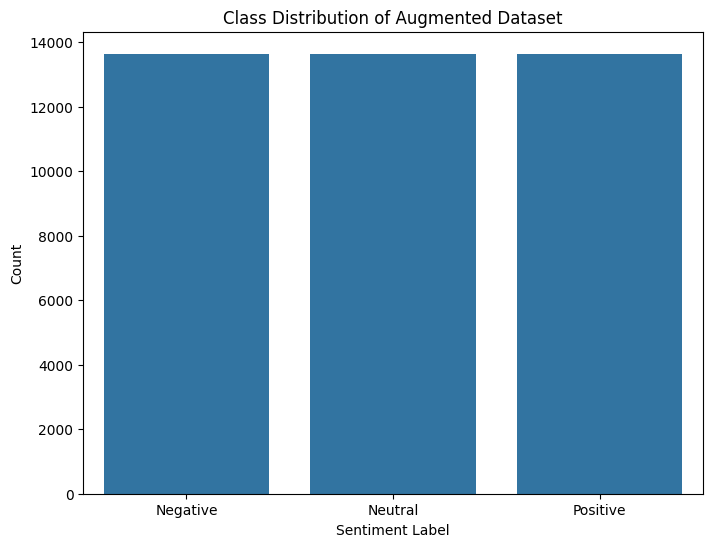

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the class distribution of the augmented dataset
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=augmented_df)
plt.title('Class Distribution of Augmented Dataset')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Negative', 'Neutral', 'Positive'])
plt.show()

## Split Data

### Subtask:
Split the balanced dataset into training and testing sets, ensuring the class distribution is maintained using stratification.

**Reasoning**:
Split the balanced dataset into training and testing sets while maintaining class distribution using stratification.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = augmented_df['cleaned_text']
y = augmented_df['label']

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (32752,)
Shape of X_test: (8189,)
Shape of y_train: (32752,)
Shape of y_test: (8189,)


## Tokenize Data

### Subtask:
Tokenize the text data for the RoBERTa model.

In [ ]:
from transformers import AutoTokenizer
import torch

# Load the pretrained RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# Tokenize the training and testing sets
# Ensure padding and truncation are applied with a suitable maximum length
train_encodings = tokenizer(list(X_train), truncation=True, padding='max_length', max_length=128, return_tensors="pt")
test_encodings = tokenizer(list(X_test), truncation=True, padding='max_length', max_length=128, return_tensors="pt")

# Convert labels to PyTorch tensors
train_labels = torch.tensor(y_train.values)
test_labels = torch.tensor(y_test.values)

print("Tokenization complete and data converted to PyTorch tensors.")

Tokenization complete and data converted to PyTorch tensors.


## Define Dataset Class

### Subtask:
Create a custom PyTorch Dataset class to handle the tokenized data and labels.

**Reasoning**:
Define a custom PyTorch Dataset class to encapsulate the tokenized inputs and labels, making it compatible with PyTorch DataLoaders and the Hugging Face Trainer.

In [ ]:
import torch
from torch.utils.data import Dataset

class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

print("Custom Dataset class defined.")

Custom Dataset class defined.


**Reasoning**:
Import the RoBERTa tokenizer, load the pretrained tokenizer, tokenize the training and testing data with padding and truncation, and convert the tokenized outputs to PyTorch tensors.

## Load RoBERTa Model

### Subtask:
Load a pretrained RoBERTa model for sequence classification.

**Reasoning**:
Load a pretrained RoBERTa model for sequence classification and print a confirmation message.

In [ ]:
from transformers import AutoModelForSequenceClassification

# Load a pretrained RoBERTa model for sequence classification with 3 output labels (for negative, neutral, positive)
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

print("Pretrained RoBERTa model loaded successfully.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pretrained RoBERTa model loaded successfully.


## Implement Hyperparameter Search

### Subtask:
Implement hyperparameter search using Optuna for learning rate and number of epochs.

**Reasoning**:
Define the model initialization function, the objective function for Optuna to optimize (based on evaluation metric), create and run the Optuna study, and print the best hyperparameters found.

In [ ]:
!pip install accelerate -U

In [ ]:
import optuna
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import torch
from torch.utils.data import Dataset # Import Dataset

# Assuming train_encodings, test_encodings, train_labels, and test_labels are already created

# Define a custom PyTorch Dataset class
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Instantiate the custom Dataset for training and testing data
train_dataset = TweetDataset(train_encodings, train_labels)
test_dataset = TweetDataset(test_encodings, test_labels)


# Define a function to compute metrics for evaluation
def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted')
    acc = accuracy_score(p.label_ids, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Define the model_init function for Optuna
def model_init(trial):
    # Load a pretrained RoBERTa model for sequence classification with 3 output labels
    return AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    num_train_epochs = trial.suggest_int("num_train_epochs", 1, 3) # Search between 1 and 3 epochs

    # Define training arguments with suggested hyperparameters and mixed precision
    training_args = TrainingArguments(
        output_dir='./results',          # output directory for checkpoints
        num_train_epochs=num_train_epochs,              # number of training epochs from Optuna trial
        per_device_train_batch_size=32,   # batch size per device during training
        per_device_eval_batch_size=32,   # batch size per device during evaluation
        weight_decay=0.01,               # weight decay
        logging_dir='./logs',            # directory for storing logs
        logging_steps=100,               # number of update steps before logging
        eval_strategy='epoch',     # evaluate at the end of each epoch
        save_strategy='epoch',           # save at the end of each epoch
        load_best_model_at_end=True,     # load the best model based on the evaluation metric at the end of training
        metric_for_best_model='eval_f1', # metric to monitor for selecting the best model - Using F1-score
        fp16=True,                       # Enable mixed precision training
        learning_rate=learning_rate,      # Use suggested learning rate
        report_to="none" # Disable reporting to Weights & Biases
    )

    # Instantiate the Trainer object
    trainer = Trainer(
        model_init=model_init, # Use model_init for hyperparameter search
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()

    # Evaluate the model on the test set and return the metric to optimize
    eval_result = trainer.evaluate()
    return eval_result["eval_f1"] # Return the evaluation F1 score for maximization


# Create an Optuna study and optimize the objective function
# We aim to maximize the evaluation F1 score
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=2) # Set a reasonable number of trials

# Print the best trial's parameters
print("Best trial:")
print("  Value (Evaluation F1 Score): {}".format(study.best_trial.value))
print("  Params: ")
for key, value in study.best_trial.params.items():
    print("    {}: {}".format(key, value))

[I 2025-10-02 00:09:06,320] A new study created in memory with name: no-name-d3f162b8-233f-4411-ba82-6d0e8148ae5e
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detac

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.488400,0.465409,0.788130,0.788787,0.788130,0.788439


C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Us

[I 2025-10-02 00:13:33,366] Trial 0 finished with value: 0.7884391505789587 and parameters: {'learning_rate': 1.495550036221987e-05, 'num_train_epochs': 1}. Best is trial 0 with value: 0.7884391505789587.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWa

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.481800,0.462033,0.790328,0.790177,0.790328,0.790243


C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


[I 2025-10-02 00:17:56,604] Trial 1 finished with value: 0.7902429948216914 and parameters: {'learning_rate': 2.030570897705402e-05, 'num_train_epochs': 1}. Best is trial 1 with value: 0.7902429948216914.


Best trial:
  Value (Evaluation F1 Score): 0.7902429948216914
  Params: 
    learning_rate: 2.030570897705402e-05
    num_train_epochs: 1


## Train Model with Best Hyperparameters

### Subtask:
Train the RoBERTa classifier using the best hyperparameters from Optuna.

**Reasoning**:
Retrieve the best hyperparameters from the Optuna study, define the `TrainingArguments` using these parameters, load a new instance of the RoBERTa model, create a `Trainer` instance with the best model and arguments, and start the training process.

In [ ]:
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification, EarlyStoppingCallback
import torch

# Updated TrainingArguments for better generalization
training_args = TrainingArguments(
    output_dir='./results_best_run',
    num_train_epochs=8,                 # more epochs for full convergence
    learning_rate=best_params.get('learning_rate', 5e-5),
    per_device_train_batch_size=best_params.get('batch_size', 32),
    per_device_eval_batch_size=best_params.get('batch_size', 32),
    gradient_accumulation_steps=2,      # effective batch doubling
    warmup_ratio=0.1,                   # 10% warmup
    weight_decay=0.01,
    logging_dir='./logs_best_run',
    logging_steps=50,
    eval_strategy='steps',        # evaluate during training
    eval_steps=100,                     # every 100 steps
    save_strategy='steps',
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    group_by_length=True,
    report_to="none",
    save_total_limit=3,
    seed=42
)

# Load model
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

# Trainer with early stopping on eval_f1
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Starting training with improved settings...")
trainer.train()
print("Training complete.")


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training with improved settings...


C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
100,1.038600,0.826936,0.634388,0.633263,0.634388,0.621234
200,0.558400,0.533346,0.763585,0.763031,0.763585,0.763279
300,0.529700,0.500563,0.776285,0.791497,0.776285,0.779942
400,0.545000,0.511612,0.774820,0.777943,0.774820,0.774235
500,0.530700,0.470155,0.786299,0.801147,0.786299,0.789048
600,0.456300,0.480482,0.784101,0.787970,0.784101,0.784763
700,0.451100,0.496206,0.766272,0.764168,0.766272,0.757118
800,0.464900,0.483979,0.781170,0.788769,0.781170,0.783586


C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Us

Training complete.


## Save the Fine-tuned Model

### Subtask:
Save the fine-tuned RoBERTa model and tokenizer to the specified local path.

**Reasoning**:
Define the local save path, create the directory if it doesn't exist, save the model using the `trainer.save_model()` method, save the tokenizer using the `tokenizer.save_pretrained()` method, and print a confirmation message.

In [ ]:
import os

# Define the local path to save the model
save_path_local = "C:\\Users\\adria\\OneDrive\\Desktop\\CODING\\jupyter\\models\\tweeteval\\robertaclassifier"

# Create the directory if it doesn't exist
os.makedirs(save_path_local, exist_ok=True)

# Save the model using the trainer
trainer.save_model(save_path_local)

# Save the tokenizer (assuming 'tokenizer' object is still available from tokenization step)
tokenizer.save_pretrained(save_path_local)

print(f"RoBERTa model and tokenizer saved to {save_path_local}")

RoBERTa model and tokenizer saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\models\tweeteval\robertaclassifier


## Generate Classification Report and Confusion Matrix

### Subtask:
Generate a classification report and confusion matrix for the trained RoBERTa model on the test set.

**Reasoning**:
Use the trained `trainer` object to get predictions on the `test_dataset`, then use `sklearn.metrics.classification_report` and `sklearn.metrics.confusion_matrix` to generate and print the report and matrix.

C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_42896\807495393.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.85      0.88      2729
     Neutral       0.66      0.81      0.72      2730
    Positive       0.83      0.70      0.76      2730

    accuracy                           0.79      8189
   macro avg       0.80      0.79      0.79      8189
weighted avg       0.80      0.79      0.79      8189



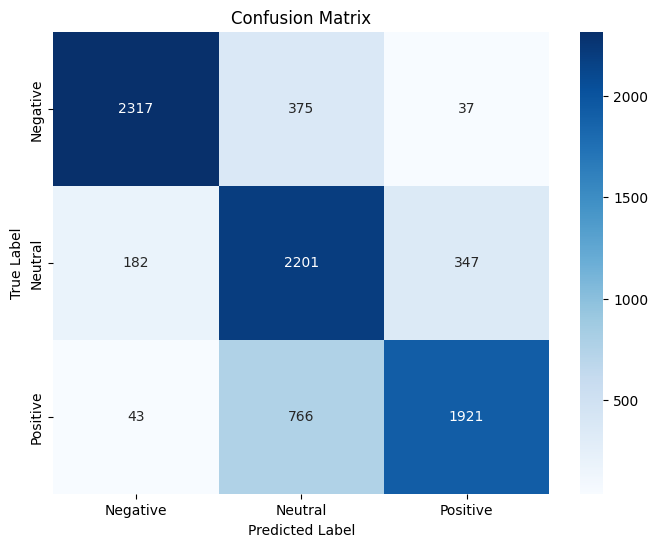

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on the test dataset
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

# Generate classification report
print("Classification Report:")
print(classification_report(labels, preds, target_names=['Negative', 'Neutral', 'Positive']))

# Generate confusion matrix
conf_matrix = confusion_matrix(labels, preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Roberta og dataset


## Load the original dataset

### Subtask:
Load the "cardiffnlp/tweet_eval" dataset with the "sentiment" configuration.


**Reasoning**:
Load the specified dataset and print its structure to understand its composition.



In [1]:
from datasets import load_dataset

# Load the "cardiffnlp/tweet_eval" dataset with the "sentiment" configuration
original_dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Print the structure of the loaded dataset
print(original_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


## Clean and preprocess data

### Subtask:
Clean and preprocess the text data from the original dataset by removing mentions, URLs, and punctuation, and handle any missing values.


**Reasoning**:
Concatenate the dataset splits, convert to pandas, handle missing values, define and apply the cleaning function, and display the results and shape.



In [2]:
import re
import pandas as pd
from datasets import concatenate_datasets

# Concatenate the dataset splits
combined_original = concatenate_datasets([
    original_dataset["train"],
    original_dataset["validation"],
    original_dataset["test"]
])

# Convert to pandas DataFrame
original_df = pd.DataFrame(combined_original)

# Check for missing values before cleaning
print("Missing values before cleaning:")
print(original_df.isnull().sum())

# Handle missing values: Drop rows where 'text' is missing
original_df.dropna(subset=['text'], inplace=True)

# Define the cleaning function
def clean_text_original(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'(@\w+|http\S+)', '', text) # Remove mentions and URLs
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

# Apply the cleaning function
original_df['cleaned_text'] = original_df['text'].apply(clean_text_original)

# Display the first few rows
display(original_df[['text', 'cleaned_text', 'label']].head())

# Print the shape after cleaning
print(f"Shape of the original DataFrame after cleaning: {original_df.shape}")

Missing values before cleaning:
text     0
label    0
dtype: int64


,text,cleaned_text,label
0,"""QT @user In the original draft of the 7th boo...",QT In the original draft of the 7th book Remus...,2
1,"""Ben Smith / Smith (concussion) remains out of...",Ben Smith Smith concussion remains out of the ...,1
2,Sorry bout the stream last night I crashed out...,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,Chase Headleys RBI double in the 8th inning of...,1
4,@user Alciato: Bee will invest 150 million in ...,Alciato Bee will invest 150 million in January...,2


Shape of the original DataFrame after cleaning: (59899, 3)


## Split data

### Subtask:
Split the cleaned original dataset into training and testing sets.


**Reasoning**:
Split the cleaned original dataset into training and testing sets.



In [3]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = original_df['cleaned_text']
y = original_df['label']

# Split the dataset into training and testing sets
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print(f"Shape of X_train_original: {X_train_original.shape}")
print(f"Shape of X_test_original: {X_test_original.shape}")
print(f"Shape of y_train_original: {y_train_original.shape}")
print(f"Shape of y_test_original: {y_test_original.shape}")

Shape of X_train_original: (47919,)
Shape of X_test_original: (11980,)
Shape of y_train_original: (47919,)
Shape of y_test_original: (11980,)


## Tokenize data

### Subtask:
Tokenize the text data using the RoBERTa tokenizer.


**Reasoning**:
Import the necessary tokenizer, load it, and tokenize the training and testing data, then convert labels to tensors.



In [4]:
from transformers import AutoTokenizer
import torch

# Load the pretrained RoBERTa tokenizer
tokenizer_original = AutoTokenizer.from_pretrained('roberta-base')

# Tokenize the training and testing sets
# Ensure padding and truncation are applied with a suitable maximum length
train_encodings_original = tokenizer_original(list(X_train_original), truncation=True, padding='max_length', max_length=128, return_tensors="pt")
test_encodings_original = tokenizer_original(list(X_test_original), truncation=True, padding='max_length', max_length=128, return_tensors="pt")

# Convert labels to PyTorch tensors
train_labels_original = torch.tensor(y_train_original.values)
test_labels_original = torch.tensor(y_test_original.values)

print("Tokenization complete and data converted to PyTorch tensors.")

Tokenization complete and data converted to PyTorch tensors.


## Define dataset class

### Subtask:
Create a custom PyTorch Dataset class to handle the tokenized data and labels.


**Reasoning**:
Define a custom PyTorch Dataset class to encapsulate the tokenized inputs and labels, making it compatible with PyTorch DataLoaders and the Hugging Face Trainer.



In [5]:
import torch
from torch.utils.data import Dataset

class TweetDatasetOriginal(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

print("Custom Dataset class defined.")

Custom Dataset class defined.


## Load roberta model

### Subtask:
Load a pretrained RoBERTa model for sequence classification.


**Reasoning**:
Load a pretrained RoBERTa model for sequence classification and print a confirmation message.



In [6]:
from transformers import AutoModelForSequenceClassification

# Load a pretrained RoBERTa model for sequence classification with 3 output labels (for negative, neutral, positive)
model_original = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

print("Pretrained RoBERTa model loaded successfully.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pretrained RoBERTa model loaded successfully.


**Reasoning**:
Instantiate the custom dataset class for the original training and testing data.



In [7]:
# Instantiate the custom Dataset for original training and testing data
train_dataset_original = TweetDatasetOriginal(train_encodings_original, train_labels_original)
test_dataset_original = TweetDatasetOriginal(test_encodings_original, test_labels_original)

print("Original training and testing datasets instantiated.")

Original training and testing datasets instantiated.


**Reasoning**:
Define the training arguments and initialize the Trainer with the original datasets and model, then start training.



In [8]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# Define a function to compute metrics for evaluation
def compute_metrics_original(p):
    preds = p.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted')
    acc = accuracy_score(p.label_ids, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Define training arguments
training_args_original = TrainingArguments(
    output_dir='./results_original',          # output directory
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=32,   # batch size per device during training
    per_device_eval_batch_size=32,   # batch size per device during evaluation
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs_original',            # directory for storing logs
    logging_steps=100,               # log every 100 steps
    eval_strategy='epoch',    # evaluate at the end of each epoch
    save_strategy='epoch',          # save at the end of each epoch
    load_best_model_at_end=True,     # load the best model based on eval_loss at the end of training
    metric_for_best_model='eval_loss', # metric to monitor for early stopping
    greater_is_better=False,         # for eval_loss, smaller is better
    fp16=torch.cuda.is_available(), # Enable mixed precision if CUDA is available
    report_to="none" # Disable reporting to Weights & Biases
)

# Initialize the Trainer
trainer_original = Trainer(
    model=model_original,
    args=training_args_original,
    train_dataset=train_dataset_original,
    eval_dataset=test_dataset_original,
    compute_metrics=compute_metrics_original
)

print("Starting training of the original model...")
# Start training
trainer_original.train()
print("Training of the original model complete.")

Starting training of the original model...


C:\Users\adria\AppData\Local\Temp\ipykernel_35044\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_35044\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.648700,0.623614,0.719783,0.722498,0.719783,0.719046
2,0.523000,0.653125,0.720451,0.724419,0.720451,0.719467
3,0.352000,0.714604,0.728715,0.728372,0.728715,0.728314


C:\Users\adria\AppData\Local\Temp\ipykernel_35044\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_35044\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])
C:\Users\adria\AppData\Local\Temp\ipykernel_35044\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:

Training of the original model complete.


## Evaluate the model

### Subtask:
Evaluate the trained model on the test set and print the evaluation metrics.

**Reasoning**:
Use the trained `trainer_original` object to evaluate the model on the `test_dataset_original` and print the resulting evaluation metrics.

In [9]:
# Evaluate the trained model on the test dataset
eval_results_original = trainer_original.evaluate()

# Print the evaluation results
print("Evaluation results for the original model:")
print(eval_results_original)

C:\Users\adria\AppData\Local\Temp\ipykernel_35044\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_35044\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Evaluation results for the original model:
{'eval_loss': 0.6236139535903931, 'eval_accuracy': 0.7197829716193657, 'eval_precision': 0.7224984111933795, 'eval_recall': 0.7197829716193657, 'eval_f1': 0.7190459068113332, 'eval_runtime': 19.9968, 'eval_samples_per_second': 599.096, 'eval_steps_per_second': 18.753, 'epoch': 3.0}


## Generate Classification Report and Confusion Matrix

### Subtask:
Generate a classification report and confusion matrix for the trained RoBERTa model on the test set.

**Reasoning**:
Use the trained `trainer_original` object to get predictions on the `test_dataset_original`, then use `sklearn.metrics.classification_report` and `sklearn.metrics.confusion_matrix` to generate and print the report and matrix.

In [13]:
import os

# Define the local path to save the model
save_path_local_original = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\tweeteval\roberta_classifier - Copy"

# Create the directory if it doesn't exist
os.makedirs(save_path_local_original, exist_ok=True)

# Save the model using the trainer
trainer_original.save_model(save_path_local_original)

# Save the tokenizer (assuming 'tokenizer_original' object is still available)
tokenizer_original.save_pretrained(save_path_local_original)

print(f"Original RoBERTa model and tokenizer saved to {save_path_local_original}")

Original RoBERTa model and tokenizer saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\tweeteval\roberta_classifier - Copy


## Load Model and Generate Classification Report

### Subtask:
Load the trained RoBERTa model and tokenizer and generate a classification report on the test set.

**Reasoning**:
Load the model and tokenizer from the saved path, use the loaded model to make predictions on the test dataset, and then generate and print the classification report using `sklearn.metrics.classification_report`.

In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Define the local path where the model and tokenizer are saved
load_path_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\tweeteval\roberta_classifier - Copy"

# Load the trained model and tokenizer
loaded_model = AutoModelForSequenceClassification.from_pretrained(load_path_local)
loaded_tokenizer = AutoTokenizer.from_pretrained(load_path_local)

print(f"Model and tokenizer loaded from {load_path_local}")

Model and tokenizer loaded from C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\tweeteval\roberta_classifier - Copy


In [4]:
from sklearn.metrics import classification_report
import torch
from torch.utils.data import DataLoader, Dataset # Import Dataset
from datasets import load_dataset, concatenate_datasets
import pandas as pd
from sklearn.model_selection import train_test_split
import re

# --- Start: Recreate test_dataset_original ---

# Load the original "cardiffnlp/tweet_eval" dataset with the "sentiment" configuration
original_dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Concatenate the dataset splits
combined_original = concatenate_datasets([
    original_dataset["train"],
    original_dataset["validation"],
    original_dataset["test"]
])

# Convert to pandas DataFrame
original_df = pd.DataFrame(combined_original)

# Handle missing values: Drop rows where 'text' is missing
original_df.dropna(subset=['text'], inplace=True)

# Define the cleaning function
def clean_text_original(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'(@\w+|http\S+)', '', text) # Remove mentions and URLs
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

# Apply the cleaning function
original_df['cleaned_text'] = original_df['text'].apply(clean_text_original)

# Define features (X) and target variable (y)
X = original_df['cleaned_text']
y = original_df['label']

# Split the dataset into training and testing sets
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X, y, test_size=0.2, random_state=42)

# Load the pretrained RoBERTa tokenizer (using the loaded_tokenizer from the previous cell)
tokenizer_original = loaded_tokenizer

# Tokenize the testing set
test_encodings_original = tokenizer_original(list(X_test_original), truncation=True, padding='max_length', max_length=128, return_tensors="pt")

# Convert labels to PyTorch tensors
test_labels_original = torch.tensor(y_test_original.values)

# Define a custom PyTorch Dataset class
class TweetDatasetOriginal(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Instantiate the custom Dataset for original testing data
test_dataset_original = TweetDatasetOriginal(test_encodings_original, test_labels_original)

# --- End: Recreate test_dataset_original ---


# Move model to GPU if available (using the loaded_model from the previous cell)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model.to(device)

# Make predictions on the test dataset
loaded_model.eval()
predictions = []
true_labels = []

test_dataloader = DataLoader(test_dataset_original, batch_size=32)

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = loaded_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Generate classification report
print("Classification Report (Loaded Model):")
print(classification_report(true_labels, predictions, target_names=['Negative', 'Neutral', 'Positive']))

C:\Users\adria\AppData\Local\Temp\ipykernel_624\1770081234.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_624\1770081234.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Classification Report (Loaded Model):
              precision    recall  f1-score   support

    Negative       0.71      0.61      0.66      2269
     Neutral       0.69      0.77      0.73      5480
    Positive       0.77      0.71      0.74      4231

    accuracy                           0.72     11980
   macro avg       0.72      0.70      0.71     11980
weighted avg       0.72      0.72      0.72     11980

